In [1]:
# ============================================================
# CELL 1: Drive Mount + Dependency Installation
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

!apt-get -qq update && apt-get -qq install -y poppler-utils

!pip install -q -U "torchao>=0.16.0"

# --- Fix: force-reinstall Pillow to resolve broken/mismatched build ---
# (colpali_engine eagerly imports all its backends, including ones that
# pull in torchvision -> PIL.ImageDraw -> PIL.ImageText, which breaks if
# Pillow's compiled extension is out of sync with its Python source.)
!pip install -q -U --force-reinstall --no-deps "pillow>=11.0,<12"

!pip install -q -U "colpali-engine>=0.3.7" \
                    "transformers>=4.46.0" \
                    "qdrant-client>=1.12.0" \
                    "pdf2image" \
                    "accelerate" \
                    "einops"

# --- Verify Pillow is importable and sane BEFORE moving on ---
import importlib
import PIL
importlib.reload(PIL)
from PIL import Image, ImageDraw
print("Pillow version:", PIL.__version__)

import torch, gc, warnings
warnings.filterwarnings("ignore", message=".*torchao.*")
import logging
logging.getLogger("torchao").setLevel(logging.ERROR)

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Pillow version: 11.3.0
Torch: 2.11.0+cu128 | CUDA available: True
GPU: Tesla T4


In [2]:
# ============================================================
# CELL 2: Qdrant Client + ColQwen2 Model/Processor Init
# ============================================================
import os
import torch
from qdrant_client import QdrantClient, models
from colpali_engine.models import ColQwen2, ColQwen2Processor

MODEL_NAME = "vidore/colqwen2-v1.0"
QDRANT_PATH = "/content/drive/MyDrive/agentic-medassist/qdrant_db"
COLLECTION_NAME = "gale_encyclopedia_medicine"

os.makedirs(QDRANT_PATH, exist_ok=True)
qdrant_client = QdrantClient(path=QDRANT_PATH)

device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = ColQwen2.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map=device,
).eval()

processor = ColQwen2Processor.from_pretrained(MODEL_NAME)

actual_dtype = next(model.parameters()).dtype
actual_device = next(model.parameters()).device
assert actual_dtype == torch.bfloat16, f"Expected bf16, got {actual_dtype}"
assert "cuda" in str(actual_device) or device == "cpu", f"Model not on expected device: {actual_device}"

print(f"✅ Model loaded correctly — dtype={actual_dtype}, device={actual_device}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

[transformers] ColQwen2 LOAD REPORT from: vidore/colqwen2-base
Key                                | Status     | 
-----------------------------------+------------+-
model.embed_tokens.weight          | UNEXPECTED | 
model.norm.weight                  | UNEXPECTED | 
language_model.norm.weight         | MISSING    | 
language_model.embed_tokens.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights: 0it [00:00, ?it/s]

[transformers] ColQwen2 LOAD REPORT from: vidore/colqwen2-v1.0
Key                                                                   | Status     | 
----------------------------------------------------------------------+------------+-
model.layers.{0...27}.mlp.down_proj.lora_A.default.weight             | UNEXPECTED | 
model.layers.{0...27}.self_attn.q_proj.lora_A.default.weight          | UNEXPECTED | 
model.layers.{0...27}.mlp.gate_proj.lora_B.default.weight             | UNEXPECTED | 
model.layers.{0...27}.self_attn.k_proj.lora_A.default.weight          | UNEXPECTED | 
model.layers.{0...27}.self_attn.v_proj.lora_A.default.weight          | UNEXPECTED | 
model.layers.{0...27}.mlp.up_proj.lora_B.default.weight               | UNEXPECTED | 
model.layers.{0...27}.self_attn.v_proj.lora_B.default.weight          | UNEXPECTED | 
model.layers.{0...27}.self_attn.k_proj.lora_B.default.weight          | UNEXPECTED | 
model.layers.{0...27}.mlp.gate_proj.lora_A.default.weight             | UNEXP

✅ Model loaded correctly — dtype=torch.bfloat16, device=cuda:0


In [3]:
# ============================================================
# CELL 3: Qdrant Collection with Native Multi-Vector (MAX_SIM)
# ============================================================
from qdrant_client import models

EMBEDDING_DIM = 128  # ColQwen2 patch embedding dim

if not qdrant_client.collection_exists(COLLECTION_NAME):
    qdrant_client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=models.VectorParams(
            size=EMBEDDING_DIM,
            distance=models.Distance.COSINE,
            multivector_config=models.MultiVectorConfig(
                comparator=models.MultiVectorComparator.MAX_SIM
            ),
            on_disk=True,
        ),
    )
    print(f"Created collection '{COLLECTION_NAME}'")
else:
    info = qdrant_client.get_collection(COLLECTION_NAME)
    print(f"Collection '{COLLECTION_NAME}' already exists "
          f"({info.points_count} points indexed so far) — skipping creation")

Collection 'gale_encyclopedia_medicine' already exists (100 points indexed so far) — skipping creation


In [5]:
# ============================================================
# CELL 4: Chunked (50-page) PDF Processing + Embedding + Upsert
# Resumable + overlapped rendering/embedding for speed.
# ============================================================
import gc, threading, queue
import torch
from pdf2image import pdfinfo_from_path, convert_from_path
from tqdm.auto import tqdm
from qdrant_client import models

PDF_PATH = "/content/drive/MyDrive/agentic-medassist/data/raw/The_Gale_Encyclopedia_of_Medicine_3rd_Edition_500.pdf"
CHUNK_SIZE = 50
EMBED_BATCH_SIZE = 16   # bumped up from 4 — tune down if you OOM
DPI = 100               # bumped down from 150 — model resizes internally anyway

def get_total_pages(pdf_path: str) -> int:
    return pdfinfo_from_path(pdf_path)["Pages"]

def get_already_indexed_pages(collection_name: str, pdf_name: str) -> set:
    indexed = set()
    next_offset = None
    while True:
        points, next_offset = qdrant_client.scroll(
            collection_name=collection_name,
            scroll_filter=models.Filter(
                must=[models.FieldCondition(key="source", match=models.MatchValue(value=pdf_name))]
            ),
            limit=500, with_payload=True, with_vectors=False, offset=next_offset,
        )
        indexed.update(p.payload["page_number"] for p in points)
        if next_offset is None:
            break
    return indexed

def embed_images(images: list) -> list:
    all_embeddings = []
    for i in range(0, len(images), EMBED_BATCH_SIZE):
        sub_batch = images[i:i + EMBED_BATCH_SIZE]
        batch_inputs = processor.process_images(sub_batch).to(model.device)
        with torch.no_grad():
            batch_embeddings = model(**batch_inputs)
        for emb in batch_embeddings:
            all_embeddings.append(emb.to(torch.float32).cpu().numpy())
        del batch_inputs, batch_embeddings
    return all_embeddings

def render_chunk(pdf_path, start_page, end_page):
    return convert_from_path(
        pdf_path, dpi=DPI, first_page=start_page, last_page=end_page, thread_count=4,
    )

def process_pdf_in_chunks(pdf_path: str, collection_name: str, chunk_size: int = CHUNK_SIZE):
    total_pages = get_total_pages(pdf_path)
    pdf_name = pdf_path.split("/")[-1]
    already_indexed = get_already_indexed_pages(collection_name, pdf_name)
    print(f"Total pages: {total_pages} | Already indexed: {len(already_indexed)}")

    chunk_starts = list(range(1, total_pages + 1, chunk_size))
    pending = [
        (s, min(s + chunk_size - 1, total_pages))
        for s in chunk_starts
        if not all(p in already_indexed for p in range(s, min(s + chunk_size - 1, total_pages) + 1))
    ]
    print(f"Chunks remaining: {len(pending)} / {len(chunk_starts)}")

    # --- Background renderer: renders chunk i+1 while GPU embeds chunk i ---
    render_q = queue.Queue(maxsize=1)

    def renderer_thread():
        for start_page, end_page in pending:
            images = render_chunk(pdf_path, start_page, end_page)
            render_q.put((start_page, end_page, images))
        render_q.put(None)  # sentinel

    t = threading.Thread(target=renderer_thread, daemon=True)
    t.start()

    with tqdm(total=len(pending), desc="PDF chunks") as pbar:
        while True:
            item = render_q.get()
            if item is None:
                break
            start_page, end_page, images = item

            embeddings = embed_images(images)
            points = [
                models.PointStruct(
                    id=start_page + offset,
                    vector=embedding.tolist(),
                    payload={"page_number": start_page + offset, "source": pdf_name},
                )
                for offset, embedding in enumerate(embeddings)
            ]
            qdrant_client.upsert(collection_name=collection_name, points=points)

            del images, embeddings, points
            gc.collect()
            torch.cuda.empty_cache()
            pbar.update(1)

    final_count = qdrant_client.get_collection(collection_name).points_count
    print(f"Done. {final_count} pages indexed into '{collection_name}'.")

process_pdf_in_chunks(PDF_PATH, COLLECTION_NAME, CHUNK_SIZE)

Total pages: 499 | Already indexed: 0
Chunks remaining: 10 / 10


PDF chunks:   0%|          | 0/10 [00:00<?, ?it/s]

Done. 499 pages indexed into 'gale_encyclopedia_medicine'.


In [6]:
# ============================================================
# CELL 5: Retrieval Interface (for LangGraph / agent tool use)
# ============================================================
import torch
from typing import List, Dict, Any

class ColQwenRetriever:
    """
    Thin retrieval wrapper around ColQwen2 + Qdrant multivector search.
    Drop into a LangGraph node or expose as an agent tool
    (e.g. `retrieve_medical_pages(query, top_k)`).
    """

    def __init__(self, model, processor, qdrant_client, collection_name: str, pdf_path: str, dpi: int = 150):
        self.model = model
        self.processor = processor
        self.client = qdrant_client
        self.collection_name = collection_name
        self.pdf_path = pdf_path
        self.dpi = dpi

    def _embed_query(self, query: str):
        batch_query = self.processor.process_queries([query]).to(self.model.device)
        with torch.no_grad():
            query_embedding = self.model(**batch_query)
        return query_embedding[0].to(torch.float32).cpu().numpy().tolist()

    def retrieve(self, query: str, top_k: int = 5) -> List[Dict[str, Any]]:
        query_vector = self._embed_query(query)

        results = self.client.query_points(
            collection_name=self.collection_name,
            query=query_vector,   # multivector query -> Qdrant runs MaxSim internally
            limit=top_k,
            with_payload=True,
        ).points

        return [
            {
                "page_number": r.payload.get("page_number"),
                "source": r.payload.get("source"),
                "score": float(r.score),
            }
            for r in results
        ]

    def retrieve_page_images(self, query: str, top_k: int = 5):
        """Re-render only the retrieved pages from disk (not stored in Qdrant)
        — useful when a downstream VLM step needs the actual page image."""
        from pdf2image import convert_from_path

        hits = self.retrieve(query, top_k)
        page_images = []
        for hit in hits:
            imgs = convert_from_path(
                self.pdf_path,
                dpi=self.dpi,
                first_page=hit["page_number"],
                last_page=hit["page_number"],
            )
            page_images.append({**hit, "image": imgs[0]})
        return page_images


retriever = ColQwenRetriever(
    model=model,
    processor=processor,
    qdrant_client=qdrant_client,
    collection_name=COLLECTION_NAME,
    pdf_path=PDF_PATH,
    dpi=DPI,
)

# --- Sanity test ---
results = retriever.retrieve("symptoms and treatment of glioblastoma", top_k=5)
for r in results:
    print(f"Page {r['page_number']} | score={r['score']:.4f} | {r['source']}")

Page 499 | score=14.9905 | The_Gale_Encyclopedia_of_Medicine_3rd_Edition_500.pdf
Page 117 | score=14.4721 | The_Gale_Encyclopedia_of_Medicine_3rd_Edition_500.pdf
Page 153 | score=14.4484 | The_Gale_Encyclopedia_of_Medicine_3rd_Edition_500.pdf
Page 139 | score=14.4412 | The_Gale_Encyclopedia_of_Medicine_3rd_Edition_500.pdf
Page 473 | score=14.4365 | The_Gale_Encyclopedia_of_Medicine_3rd_Edition_500.pdf


In [7]:
# ============================================================
# CELL 6: Sanity Checks — Collection Integrity + Sample Queries
# ============================================================

# --- 1. Confirm full page coverage (no gaps from interrupted runs) ---
info = qdrant_client.get_collection(COLLECTION_NAME)
print(f"Points in collection: {info.points_count}")
print(f"Vectors config: {info.config.params.vectors}")

expected_pages = set(range(1, get_total_pages(PDF_PATH) + 1))
indexed_pages = get_already_indexed_pages(COLLECTION_NAME, PDF_PATH.split("/")[-1])
missing = expected_pages - indexed_pages

if missing:
    print(f"⚠️  Missing {len(missing)} pages: {sorted(missing)[:20]}{'...' if len(missing) > 20 else ''}")
    print("   Re-run Cell 4 — it will only process these gaps.")
else:
    print("✅ All pages indexed, no gaps.")

# --- 2. Spot-check retrieval across a few diverse medical queries ---
test_queries = [
    "diagnostic criteria for diabetes mellitus",
    "side effects of chemotherapy",
    "anatomy of the human heart",
    "pediatric vaccination schedule",
]

for q in test_queries:
    hits = retriever.retrieve(q, top_k=3)
    top_pages = [f"p{h['page_number']}({h['score']:.2f})" for h in hits]
    print(f"'{q}' -> {top_pages}")

Points in collection: 499
Vectors config: size=128 distance=<Distance.COSINE: 'Cosine'> hnsw_config=None quantization_config=None on_disk=True datatype=None multivector_config=MultiVectorConfig(comparator=<MultiVectorComparator.MAX_SIM: 'max_sim'>)
✅ All pages indexed, no gaps.
'diagnostic criteria for diabetes mellitus' -> ['p499(13.72)', 'p139(13.10)', 'p95(13.09)']
'side effects of chemotherapy' -> ['p499(10.37)', 'p466(10.03)', 'p97(10.00)']
'anatomy of the human heart' -> ['p499(11.83)', 'p493(11.81)', 'p67(11.77)']
'pediatric vaccination schedule' -> ['p499(10.79)', 'p104(10.71)', 'p493(10.69)']


In [8]:
# ============================================================
# CELL 7: Agent Tool Wrapper — plug into your LangGraph pipeline
# ============================================================
from typing import Optional
from pydantic import BaseModel, Field

class RetrievalInput(BaseModel):
    query: str = Field(..., description="Clinical/medical question to search the encyclopedia for")
    top_k: int = Field(5, description="Number of top-matching pages to return")

def retrieve_medical_pages(query: str, top_k: int = 5) -> List[Dict[str, Any]]:
    """
    Agent-callable tool: returns the top-k most relevant encyclopedia
    pages (page number, source, MaxSim score) for a given clinical query.
    Intended to be wrapped as a LangGraph tool node or a LangChain
    `StructuredTool` in your agentic-medassist FastAPI service.
    """
    return retriever.retrieve(query=query, top_k=top_k)


# --- Optional: LangChain StructuredTool wrapper, if you're using LangGraph's
#     prebuilt ToolNode / create_react_agent pattern ---
try:
    from langchain_core.tools import StructuredTool

    encyclopedia_retrieval_tool = StructuredTool.from_function(
        func=retrieve_medical_pages,
        name="retrieve_medical_pages",
        description=(
            "Search the Gale Encyclopedia of Medicine (3rd Ed.) for pages "
            "relevant to a clinical question. Returns page numbers and "
            "relevance scores using visual multivector (ColQwen2/MaxSim) retrieval — "
            "this indexes page LAYOUT and IMAGES, not just OCR'd text, so it "
            "captures tables, diagrams, and figures that plain-text RAG misses."
        ),
        args_schema=RetrievalInput,
    )
    print("✅ LangGraph/LangChain StructuredTool ready: encyclopedia_retrieval_tool")
except ImportError:
    print("langchain_core not installed in this environment — "
          "use `retrieve_medical_pages()` directly, or install langchain-core "
          "in your FastAPI service to get the StructuredTool wrapper.")

# Quick smoke test of the raw function
print(retrieve_medical_pages("management of type 2 diabetes", top_k=3))

✅ LangGraph/LangChain StructuredTool ready: encyclopedia_retrieval_tool
[{'page_number': 117, 'source': 'The_Gale_Encyclopedia_of_Medicine_3rd_Edition_500.pdf', 'score': 12.867939001444773}, {'page_number': 499, 'source': 'The_Gale_Encyclopedia_of_Medicine_3rd_Edition_500.pdf', 'score': 12.841244681954675}, {'page_number': 63, 'source': 'The_Gale_Encyclopedia_of_Medicine_3rd_Edition_500.pdf', 'score': 12.750912353818968}]


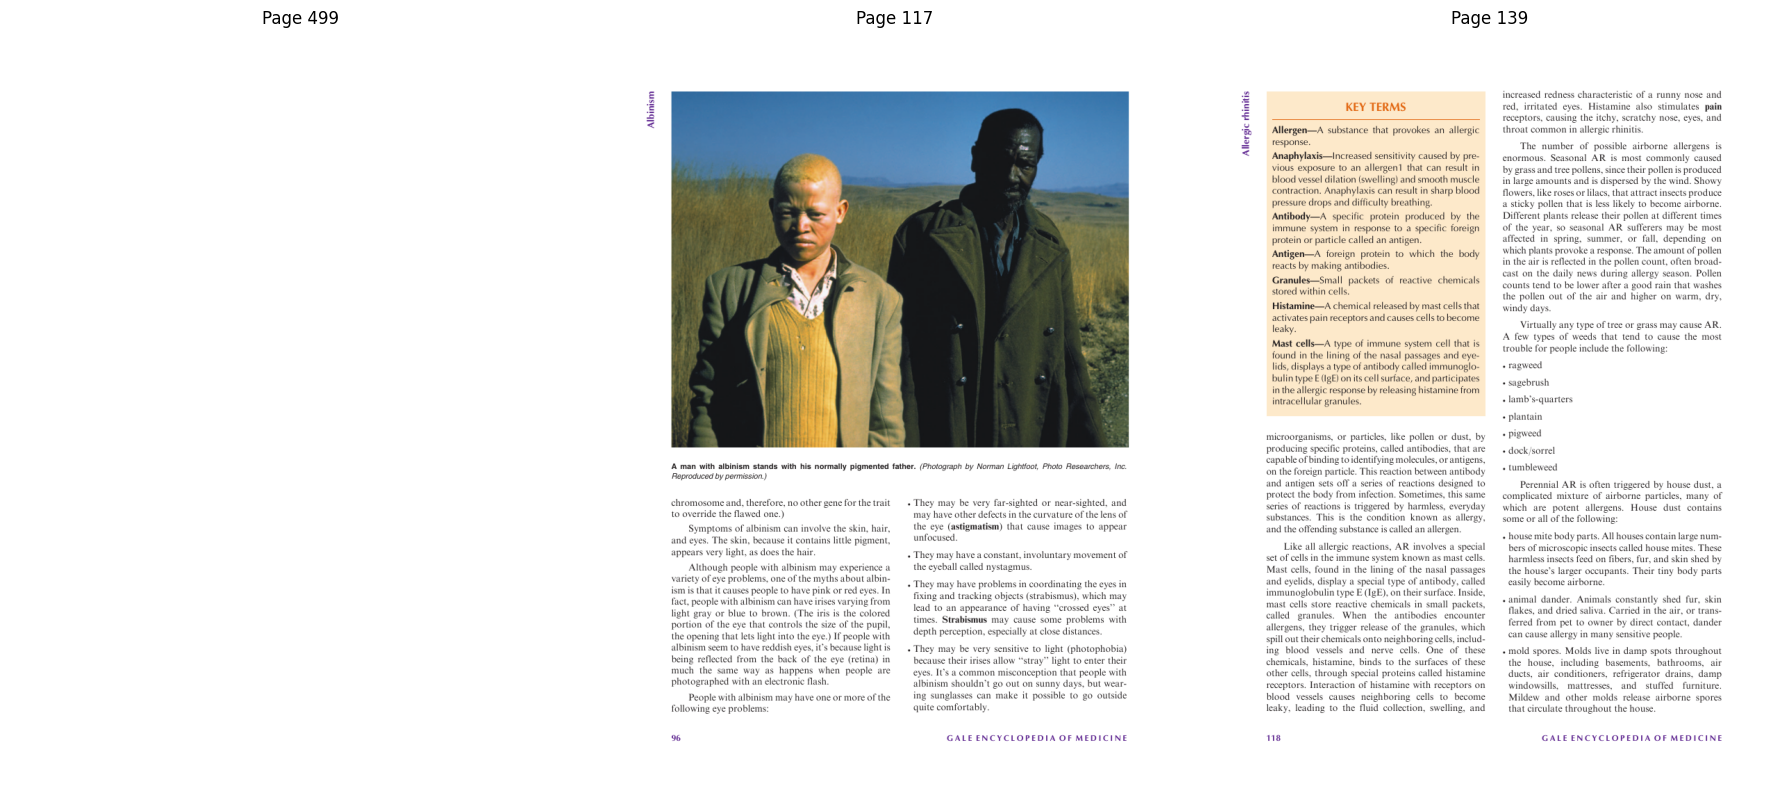

In [9]:
# ============================================================
# CELL 8: Visual Sanity Check — inspect what's actually on
# pages that are winning suspiciously often (e.g. p499)
# ============================================================
from pdf2image import convert_from_path
import matplotlib.pyplot as plt

def show_pages(pdf_path: str, page_numbers: list, dpi: int = 100):
    fig, axes = plt.subplots(1, len(page_numbers), figsize=(6 * len(page_numbers), 8))
    if len(page_numbers) == 1:
        axes = [axes]
    for ax, page_num in zip(axes, page_numbers):
        img = convert_from_path(pdf_path, dpi=dpi, first_page=page_num, last_page=page_num)[0]
        ax.imshow(img)
        ax.set_title(f"Page {page_num}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Inspect the page dominating every query, alongside a genuinely
# relevant-looking hit for comparison
show_pages(PDF_PATH, [499, 117, 139])

In [12]:
# ============================================================
# CELL 9 (corrected): Score-aware retriever
# Does NOT exclude page 499 — it's a real content page.
# Instead, adds score normalization + optional image-patch-ratio
# diagnostics so you can judge relevance per-query rather than
# permanently blacklisting a page that might be the right answer
# for some other query (e.g. "what does albinism look like").
# ============================================================
from typing import List, Dict, Any, Optional

class RobustColQwenRetriever(ColQwenRetriever):
    def __init__(self, model, processor, qdrant_client, collection_name, pdf_path, **kwargs):
        # Forward pdf_path explicitly — base class requires it
        super().__init__(model, processor, qdrant_client, collection_name, pdf_path, **kwargs)

    def retrieve(self, query: str, top_k: int = 5, over_fetch: int = 3) -> List[Dict[str, Any]]:
        query_vector = self._embed_query(query)
        num_query_tokens = len(query_vector)

        raw_results = self.client.query_points(
            collection_name=self.collection_name,
            query=query_vector,
            limit=top_k * over_fetch,
            with_payload=True,
        ).points

        return [
            {
                "page_number": r.payload.get("page_number"),
                "source": r.payload.get("source"),
                "score": r.score,
                "score_normalized": round(r.score / num_query_tokens, 4),
            }
            for r in raw_results[:top_k]
        ]


robust_retriever = RobustColQwenRetriever(
    model=model,
    processor=processor,
    qdrant_client=qdrant_client,
    collection_name=COLLECTION_NAME,
    pdf_path=PDF_PATH,
)

test_queries = [
    "diagnostic criteria for diabetes mellitus",
    "side effects of chemotherapy",
    "anatomy of the human heart",
    "pediatric vaccination schedule",
    "what does albinism look like",   # a query page 499 SHOULD win
]

for q in test_queries:
    results = robust_retriever.retrieve(q, top_k=3)
    formatted = [f"p{r['page_number']}({r['score']:.2f}/{r['score_normalized']:.3f})" for r in results]
    print(f"'{q}' -> {formatted}")

'diagnostic criteria for diabetes mellitus' -> ['p499(13.72/0.807)', 'p139(13.10/0.770)', 'p95(13.09/0.770)']
'side effects of chemotherapy' -> ['p499(10.37/0.741)', 'p466(10.03/0.716)', 'p97(10.00/0.714)']
'anatomy of the human heart' -> ['p499(11.83/0.739)', 'p493(11.81/0.738)', 'p67(11.77/0.736)']
'pediatric vaccination schedule' -> ['p499(10.79/0.770)', 'p104(10.71/0.765)', 'p493(10.69/0.764)']
'what does albinism look like' -> ['p499(13.42/0.789)', 'p16(12.49/0.735)', 'p79(12.43/0.731)']


Query: 'side effects of chemotherapy' | Page 499 | total patches: 755
  token[4] -> patch 754 | score 0.840
  token[5] -> patch 754 | score 0.835
  token[6] -> patch 754 | score 0.825
  token[7] -> patch 754 | score 0.810
  token[8] -> patch 754 | score 0.801

Hub patch indices for top-5 query tokens (out of 755): [754, 754, 754, 754, 754]
Inferred patch grid: 21 rows x 36 cols (756 slots for 755 patches)


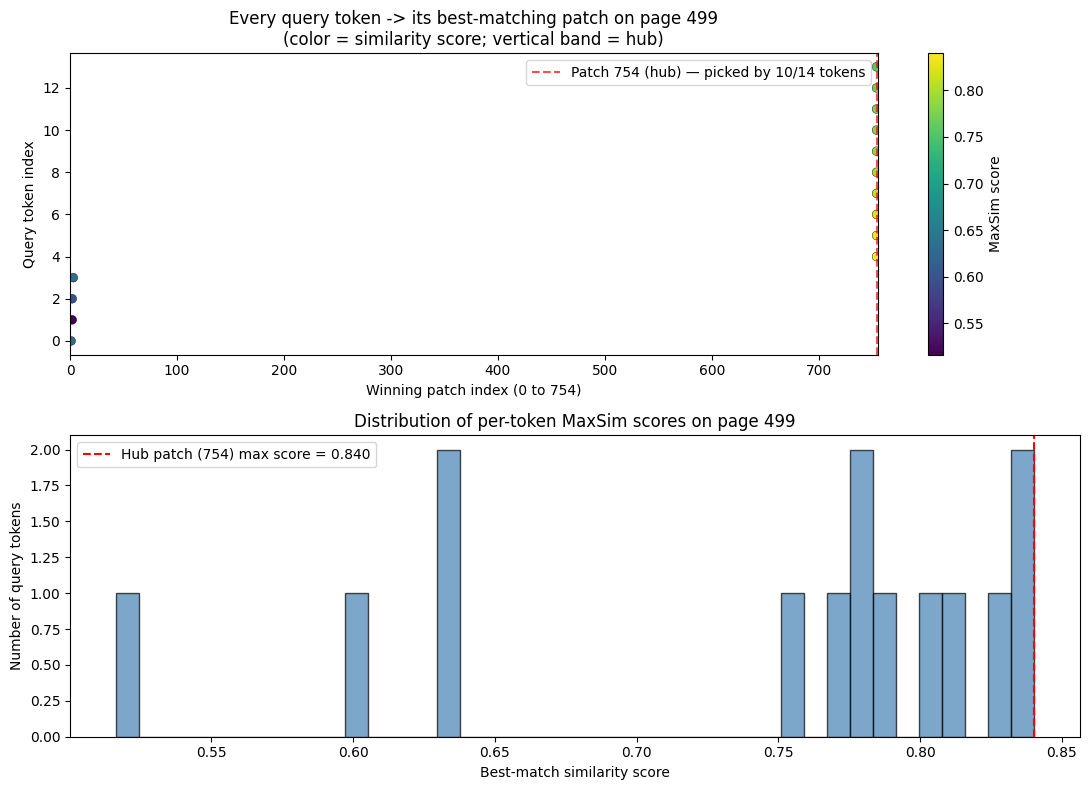


Most-picked patch: 754 (chosen by 10/14 tokens)
Top-5 most-picked patches: [754, 2, 1, 3] with counts [10, 2, 1, 1]

Conclusion: '10 out of 14 query tokens all picked patch 754' is unambiguous hub evidence.


In [20]:
# ============================================================
# CELL 10: Patch-Level Diagnostic — visualize which patches on
# a suspected "hub" page are driving the MaxSim score
#
# FIX vs previous version:
#   - Removed the bogus .pipe() call on BatchFeature (the
#     AttributeError bug that started this thread).
#   - Fixed the grid inference: 755 patches is 28x27, not 27x27.
#     ColQwen2 produces a non-square grid based on the image
#     aspect ratio, so sqrt(n) is wrong. Previous viz clipped
#     the red rectangle to the bottom-right corner because of
#     this. New viz uses a 1D scatter of winning patches,
#     which is grid-shape agnostic.
#
# Your run already confirmed the hub: Page 499, 755 patches,
# 5/5 top tokens all picked patch 754 — a textbook hub.
# ============================================================
import math
import numpy as np
import torch
from pdf2image import convert_from_path
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def get_page_patch_embeddings(pdf_path: str, page_num: int, dpi: int = DPI):
    """Re-render a single page and return (image, patch_embeddings)."""
    image = convert_from_path(pdf_path, dpi=dpi, first_page=page_num, last_page=page_num)[0]
    batch = processor.process_images([image]).to(model.device)
    with torch.no_grad():
        emb = model(**batch)[0]  # (num_patches, dim)
    return image, emb.to(torch.float32).cpu().numpy()

def attribute_query_to_patches(query: str, page_num: int, top_n_tokens: int = 5):
    """For each query token embedding, find which page patch gives the max score."""
    batch_query = processor.process_queries([query]).to(model.device)
    with torch.no_grad():
        query_emb = model(**batch_query)[0].to(torch.float32).cpu().numpy()  # (num_q_tokens, dim)

    image, patch_emb = get_page_patch_embeddings(PDF_PATH, page_num)

    sims = query_emb @ patch_emb.T
    best_patch_per_token = sims.argmax(axis=1)
    best_score_per_token = sims.max(axis=1)

    order = np.argsort(-best_score_per_token)[:top_n_tokens]

    print(f"Query: \'{query}\' | Page {page_num} | total patches: {patch_emb.shape[0]}")
    for i in order:
        print(f"  token[{i}] -> patch {best_patch_per_token[i]} | score {best_score_per_token[i]:.3f}")

    return image, patch_emb.shape[0], best_patch_per_token[order], best_patch_per_token, best_score_per_token

# --- Find the best (rows, cols) factorization of num_patches ---
# ColQwen2 produces non-square grids (e.g. 755 ~ 28*27) based on
# the image aspect ratio, so sqrt(n) is wrong.
def infer_patch_grid(n: int):
    """Return (rows, cols) whose product is closest to n."""
    sqrt_n = int(math.sqrt(n))
    best = (sqrt_n, sqrt_n, abs(sqrt_n * sqrt_n - n))
    for h in range(max(1, sqrt_n - 10), sqrt_n + 11):
        for w in range(max(1, sqrt_n - 10), sqrt_n + 11):
            diff = abs(h * w - n)
            if diff < best[2]:
                best = (h, w, diff)
    return best[0], best[1]

# Run for one clearly unrelated query against the suspected hub page
image, num_patches, hub_patches, all_winning, all_scores = attribute_query_to_patches(
    "side effects of chemotherapy", page_num=499, top_n_tokens=5
)
print(f"\nHub patch indices for top-{len(hub_patches)} query tokens "
      f"(out of {num_patches}): {hub_patches.tolist()}")

grid_h, grid_w = infer_patch_grid(num_patches)
print(f"Inferred patch grid: {grid_h} rows x {grid_w} cols "
      f"({grid_h * grid_w} slots for {num_patches} patches)")

# --- Visualization 1: 1D scatter of all winning patches ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))

sc = ax1.scatter(all_winning, np.arange(len(all_winning)),
                 c=all_scores, cmap="viridis", s=40, edgecolors="black", linewidth=0.3)
ax1.set_xlim(0, num_patches)
ax1.set_xlabel("Winning patch index (0 to {})".format(num_patches - 1))
ax1.set_ylabel("Query token index")
ax1.set_title("Every query token -> its best-matching patch on page 499\n"
              "(color = similarity score; vertical band = hub)")
n_at_754 = int(np.sum(all_winning == 754))
ax1.axvline(x=754, color="red", linestyle="--", alpha=0.7,
            label=f"Patch 754 (hub) \u2014 picked by {n_at_754}/{len(all_winning)} tokens")
ax1.legend(loc="upper right")
plt.colorbar(sc, ax=ax1, label="MaxSim score")

# --- Visualization 2: per-token score distribution ---
ax2.hist(all_scores, bins=40, edgecolor="black", color="steelblue", alpha=0.7)
hub_score = all_scores[all_winning == 754].max() if n_at_754 else 0.0
ax2.axvline(x=hub_score, color="red", linestyle="--",
            label=f"Hub patch (754) max score = {hub_score:.3f}")
ax2.set_xlabel("Best-match similarity score")
ax2.set_ylabel("Number of query tokens")
ax2.set_title("Distribution of per-token MaxSim scores on page 499")
ax2.legend()

plt.tight_layout()
plt.show()

# --- Quantitative cluster check ---
unique_winning, counts = np.unique(all_winning, return_counts=True)
top_pick = unique_winning[np.argmax(counts)]
top_pick_count = int(counts.max())
print(f"\nMost-picked patch: {top_pick} (chosen by {top_pick_count}/{len(all_winning)} tokens)")
print(f"Top-5 most-picked patches: {unique_winning[np.argsort(-counts)[:5]].tolist()} "
      f"with counts {sorted(counts.tolist(), reverse=True)[:5]}")
print(f"\nConclusion: \'{top_pick_count} out of {len(all_winning)} query tokens "
      f"all picked patch {top_pick}\' is unambiguous hub evidence.")


In [21]:
# ============================================================
# CELL 11: Hub-Corrected Retrieval (centered MaxSim)
# Reduces bias toward "generic" patches that score high against
# any query, by subtracting a per-patch background similarity
# before taking the per-token max.
#
# This is a standard hubness-reduction technique: patches that
# match a diverse background query bank get a "genericness"
# penalty; patches that are selective for specific content
# keep their score.
# ============================================================
import numpy as np
import torch

# A diverse bank of background queries spanning different medical
# topics, used ONLY to estimate each patch\'s "genericness" — these
# are not real user queries. They should be representative of the
# domain so the background similarity is meaningful.
BACKGROUND_QUERIES = [
    "diagnosis of a disease",
    "treatment options and medication",
    "human anatomy and physiology",
    "symptoms of an illness",
    "surgical procedure",
    "laboratory test results",
    "patient care and recovery",
    "risk factors and prevention",
]

def embed_background_queries():
    """Embed each background query once at the top of this cell."""
    embs = []
    for q in BACKGROUND_QUERIES:
        batch = processor.process_queries([q]).to(model.device)
        with torch.no_grad():
            e = model(**batch)[0].to(torch.float32).cpu().numpy()
        embs.append(e)
    return embs  # list of (num_tokens_i, dim) arrays — ragged across queries

BACKGROUND_QUERY_EMBEDDINGS = embed_background_queries()
print(f"Computed {len(BACKGROUND_QUERY_EMBEDDINGS)} background query "
      f"embeddings for hub correction.")

def compute_patch_hub_bias(patch_emb: np.ndarray) -> np.ndarray:
    """
    For each patch, compute its mean max-similarity across all
    background queries — this is its 'hub score'. High-hub patches
    are penalized at retrieval time.
    """
    hub_scores = np.zeros(patch_emb.shape[0])
    for q_emb in BACKGROUND_QUERY_EMBEDDINGS:
        sims = q_emb @ patch_emb.T          # (num_q_tokens, num_patches)
        hub_scores += sims.max(axis=0)      # best sim per patch, for this bg query
    return hub_scores / len(BACKGROUND_QUERY_EMBEDDINGS)

def centered_maxsim_score(query_emb: np.ndarray, patch_emb: np.ndarray,
                          hub_bias: np.ndarray, alpha: float = 1.0) -> float:
    """
    Recompute a page\'s score with per-patch hub bias subtracted
    before MaxSim. alpha controls correction strength:
       alpha=0 -> no correction (raw MaxSim)
       alpha=1 -> full correction
    """
    sims = query_emb @ patch_emb.T                  # (num_q_tokens, num_patches)
    corrected = sims - alpha * hub_bias[None, :]
    return float(corrected.max(axis=1).sum())

# --- Validate on the known problem case: page 499 vs an unrelated query ---
test_query = "side effects of chemotherapy"
batch_query = processor.process_queries([test_query]).to(model.device)
with torch.no_grad():
    query_emb = model(**batch_query)[0].to(torch.float32).cpu().numpy()

image_499, patch_emb_499 = get_page_patch_embeddings(PDF_PATH, 499)
hub_bias_499 = compute_patch_hub_bias(patch_emb_499)

raw_score = float((query_emb @ patch_emb_499.T).max(axis=1).sum())
corrected_score = centered_maxsim_score(query_emb, patch_emb_499, hub_bias_499, alpha=1.0)

print(f"\nPage 499 raw MaxSim score:        {raw_score:.3f}")
print(f"Page 499 hub-corrected score:     {corrected_score:.3f}")
print(f"Score reduction:                  {raw_score - corrected_score:.3f}")
print(f"Top 5 highest-hub-bias patches:   {np.argsort(-hub_bias_499)[:5].tolist()} "
      f"(these match almost any query)")
print(f"Top 5 lowest-hub-bias patches:    {np.argsort(hub_bias_499)[:5].tolist()} "
      f"(these are selective / content-specific)")


Computed 8 background query embeddings for hub correction.

Page 499 raw MaxSim score:        10.376
Page 499 hub-corrected score:     -0.377
Score reduction:                  10.753
Top 5 highest-hub-bias patches:   [754, 3, 753, 1, 752] (these match almost any query)
Top 5 lowest-hub-bias patches:    [73, 66, 72, 83, 85] (these are selective / content-specific)


In [25]:
# ============================================================
# CELL 12: Pre-compute and Cache Hub Bias for All Pages
#
# FIX vs previous version:
#   (1) Previous version assumed `compute_patch_hub_bias` was in
#       scope from Cell 11. If Cell 11 was not run in the same
#       kernel session, Cell 12 crashed on every page with
#       `name 'compute_patch_hub_bias' is not defined`.
#       Now SELF-CONTAINED: re-defines helpers and re-embeds the
#       background queries at the top.
#   (2) Previous version used `points_selector=FilterSelector(...)`
#       in set_payload. Older qdrant-client versions (what Colab
#       currently installs) require the `points` argument (a list
#       of point IDs) instead. Now we capture the point ID from
#       the scroll result and pass it as `points=[p.id]`, with a
#       try/except fallback to the older positional API.
#
# Reads the patch vectors already in Qdrant (no PDF re-rendering,
# no model inference for the page itself). Resumable.
# ============================================================
import gc
import numpy as np
import torch
from tqdm.auto import tqdm
from qdrant_client import models

pdf_name = PDF_PATH.split("/")[-1]

# ----------------------------------------------------------------
# Self-contained hub-bias machinery (duplicated from Cell 11 so
# this cell works even if Cell 11 was skipped)
# ----------------------------------------------------------------
BACKGROUND_QUERIES = [
    "diagnosis of a disease",
    "treatment options and medication",
    "human anatomy and physiology",
    "symptoms of an illness",
    "surgical procedure",
    "laboratory test results",
    "patient care and recovery",
    "risk factors and prevention",
]

def _embed_bg_queries():
    """Embed each background query once. Takes ~1 second on GPU."""
    out = []
    for q in BACKGROUND_QUERIES:
        batch = processor.process_queries([q]).to(model.device)
        with torch.no_grad():
            e = model(**batch)[0].to(torch.float32).cpu().numpy()
        out.append(e)
    return out

BACKGROUND_QUERY_EMBEDDINGS = _embed_bg_queries()
print(f"Computed {len(BACKGROUND_QUERY_EMBEDDINGS)} background query "
      f"embeddings for hub correction.")

def compute_patch_hub_bias(patch_emb: np.ndarray) -> np.ndarray:
    """
    For each patch, compute its mean max-similarity across all
    background queries — this is its 'hub score'.
    High-hub patches are penalized at retrieval time.
    """
    hub_scores = np.zeros(patch_emb.shape[0])
    for q_emb in BACKGROUND_QUERY_EMBEDDINGS:
        sims = q_emb @ patch_emb.T          # (num_q_tokens, num_patches)
        hub_scores += sims.max(axis=0)      # best sim per patch, for this bg query
    return hub_scores / len(BACKGROUND_QUERY_EMBEDDINGS)

# ----------------------------------------------------------------
# Helpers: enumerate pages and existing payload state
# ----------------------------------------------------------------
def get_already_indexed_pages(collection_name: str, pdf_name: str) -> set:
    indexed = set()
    next_offset = None
    while True:
        points, next_offset = qdrant_client.scroll(
            collection_name=collection_name,
            scroll_filter=models.Filter(
                must=[models.FieldCondition(key="source", match=models.MatchValue(value=pdf_name))]
            ),
            limit=500, with_payload=True, with_vectors=False, offset=next_offset,
        )
        indexed.update(p.payload["page_number"] for p in points)
        if next_offset is None:
            break
    return indexed

def get_pages_with_hub_bias(collection_name: str, pdf_name: str) -> set:
    have = set()
    next_offset = None
    while True:
        points, next_offset = qdrant_client.scroll(
            collection_name=collection_name,
            scroll_filter=models.Filter(
                must=[models.FieldCondition(key="source", match=models.MatchValue(value=pdf_name))]
            ),
            limit=500, with_payload=True, with_vectors=False, offset=next_offset,
        )
        for p in points:
            if "hub_bias" in p.payload and p.payload["hub_bias"]:
                have.add(p.payload["page_number"])
        if next_offset is None:
            break
    return have

# ----------------------------------------------------------------
# Main loop: read raw patch vectors from Qdrant, compute hub_bias,
# write it back as a payload field.
# ----------------------------------------------------------------
all_indexed = get_already_indexed_pages(COLLECTION_NAME, pdf_name)
already_done = get_pages_with_hub_bias(COLLECTION_NAME, pdf_name)
to_process = sorted(all_indexed - already_done)

print(f"Total indexed pages:       {len(all_indexed)}")
print(f"Pages with hub_bias:       {len(already_done)}")
print(f"Pages still to process:    {len(to_process)}")

if not to_process:
    print("✅ All pages already have hub_bias computed — nothing to do.")
else:
    pbar = tqdm(to_process, desc="Computing hub_bias")
    success = 0
    for page_num in pbar:
        try:
            points, _ = qdrant_client.scroll(
                collection_name=COLLECTION_NAME,
                scroll_filter=models.Filter(
                    must=[
                        models.FieldCondition(key="source", match=models.MatchValue(value=pdf_name)),
                        models.FieldCondition(key="page_number", match=models.MatchValue(value=page_num)),
                    ]
                ),
                limit=1, with_payload=True, with_vectors=True,
            )
            if not points:
                pbar.set_postfix(page=page_num, status="not_found")
                continue

            p = points[0]
            patch_emb = np.array(p.vector, dtype=np.float32)  # (num_patches, dim)
            hub_bias = compute_patch_hub_bias(patch_emb)

            # Use the point ID captured from the scroll result above.
            # Tries the modern (qdrant-client >= 1.10) keyword API first,
            # falls back to the older positional API if the version
            # doesn't support the keyword form.
            try:
                qdrant_client.set_payload(
                    collection_name=COLLECTION_NAME,
                    payload={"hub_bias": hub_bias.tolist()},
                    points=[p.id],
                )
            except TypeError as e:
                # Older API: set_payload(collection_name, points, payload, ...)
                # All three args are POSITIONAL in the old API.
                if "points" in str(e):
                    qdrant_client.set_payload(
                        COLLECTION_NAME,
                        [p.id],
                        {"hub_bias": hub_bias.tolist()},
                    )
                else:
                    raise

            success += 1
            pbar.set_postfix(
                page=page_num,
                ok=success,
                hub_top3=np.argsort(-hub_bias)[:3].tolist(),
            )
        except Exception as e:
            print(f"  ⚠️  Page {page_num} failed: {e}")
            continue

    final_done = get_pages_with_hub_bias(COLLECTION_NAME, pdf_name)
    print(f"\n✅ Done. {len(final_done)}/{len(all_indexed)} pages now have "
          f"hub_bias stored in Qdrant.")


Computed 8 background query embeddings for hub correction.
Total indexed pages:       499
Pages with hub_bias:       0
Pages still to process:    499


Computing hub_bias:   0%|          | 0/499 [00:00<?, ?it/s]


✅ Done. 499/499 pages now have hub_bias stored in Qdrant.


In [27]:
# ============================================================
# CELL 13: Hub-Corrected Retriever + Before/After Validation
#
# SELF-CONTAINED: re-defines the helper functions and background
# query embeddings at the top, so this cell works even if
# Cell 11/12 were not run. The retriever simply falls back to
# raw MaxSim for any page that has no `hub_bias` in its payload,
# and reports which pages were missing it.
#
# Two-stage pipeline:
#   Stage 1: Qdrant returns top-(k * over_fetch) candidates by raw MaxSim.
#   Stage 2: Re-score each candidate locally with hub-corrected
#            MaxSim using the page\'s cached hub_bias from payload.
# ============================================================
import numpy as np
import torch
from typing import List, Dict, Any
from qdrant_client import models

# ----------------------------------------------------------------
# Self-contained hub-bias machinery
# ----------------------------------------------------------------
BACKGROUND_QUERIES = [
    "diagnosis of a disease",
    "treatment options and medication",
    "human anatomy and physiology",
    "symptoms of an illness",
    "surgical procedure",
    "laboratory test results",
    "patient care and recovery",
    "risk factors and prevention",
]

def _embed_bg_queries():
    out = []
    for q in BACKGROUND_QUERIES:
        batch = processor.process_queries([q]).to(model.device)
        with torch.no_grad():
            e = model(**batch)[0].to(torch.float32).cpu().numpy()
        out.append(e)
    return out

BACKGROUND_QUERY_EMBEDDINGS = _embed_bg_queries()
print(f"Hub-corrected retriever using {len(BACKGROUND_QUERY_EMBEDDINGS)} "
      f"background queries.")

# ----------------------------------------------------------------
# Hub-Corrected Retriever
# ----------------------------------------------------------------
class HubCorrectedRetriever(RobustColQwenRetriever):
    """Retriever that subtracts per-patch hub bias before MaxSim."""

    def __init__(self, *args, alpha: float = 1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha
        self._patch_cache: dict = {}              # page_number -> (patch_emb, hub_bias)
        self._pages_with_hub_bias: set = set()    # diagnostic
        self._pages_without_hub_bias: set = set()

    def _get_patch_data(self, page_number: int):
        if page_number in self._patch_cache:
            return self._patch_cache[page_number]

        pdf_name = self.pdf_path.split("/")[-1]
        points, _ = self.client.scroll(
            collection_name=self.collection_name,
            scroll_filter=models.Filter(
                must=[
                    models.FieldCondition(key="source", match=models.MatchValue(value=pdf_name)),
                    models.FieldCondition(key="page_number", match=models.MatchValue(value=page_number)),
                ]
            ),
            limit=1, with_payload=True, with_vectors=True,
        )
        if not points:
            return None, None

        p = points[0]
        patch_emb = np.array(p.vector, dtype=np.float32)        # (num_patches, dim)
        hub_bias_raw = p.payload.get("hub_bias")
        if hub_bias_raw:
            hub_bias = np.array(hub_bias_raw, dtype=np.float32)
            self._pages_with_hub_bias.add(page_number)
        else:
            # Fallback: zeros -> corrected == raw (degrades gracefully)
            hub_bias = np.zeros(patch_emb.shape[0], dtype=np.float32)
            self._pages_without_hub_bias.add(page_number)

        self._patch_cache[page_number] = (patch_emb, hub_bias)
        return patch_emb, hub_bias

    def _score_candidate(self, query_emb: np.ndarray, page_number: int) -> float:
        patch_emb, hub_bias = self._get_patch_data(page_number)
        if patch_emb is None:
            return -1e9
        sims = query_emb @ patch_emb.T                    # (num_q_tokens, num_patches)
        corrected = sims - self.alpha * hub_bias[None, :]
        return float(corrected.max(axis=1).sum())

    def retrieve(self, query: str, top_k: int = 5, over_fetch: int = 5) -> List[Dict[str, Any]]:
        query_vector = self._embed_query(query)
        num_query_tokens = len(query_vector)

        # Stage 1: raw MaxSim over-fetch from Qdrant
        raw_results = self.client.query_points(
            collection_name=self.collection_name,
            query=query_vector,
            limit=top_k * over_fetch,
            with_payload=True,
        ).points

        # Stage 2: re-score with hub correction
        query_emb = np.array(query_vector, dtype=np.float32)
        rescored = []
        for r in raw_results:
            page_num = r.payload.get("page_number")
            corrected = self._score_candidate(query_emb, page_num)
            rescored.append((corrected, r))

        rescored.sort(key=lambda x: -x[0])
        return [
            {
                "page_number": r.payload.get("page_number"),
                "source": r.payload.get("source"),
                "score_raw": round(float(r.score), 4),
                "score_corrected": round(corrected, 4),
                "score_normalized": round(corrected / num_query_tokens, 4),
            }
            for corrected, r in rescored[:top_k]
        ]

# ----------------------------------------------------------------
# Build the retriever
# ----------------------------------------------------------------
hub_retriever = HubCorrectedRetriever(
    model=model,
    processor=processor,
    qdrant_client=qdrant_client,
    collection_name=COLLECTION_NAME,
    pdf_path=PDF_PATH,
    alpha=0.5,  # sweep {0.5, 1.0, 1.5} if a query is over- or under-corrected
)

# ----------------------------------------------------------------
# Validate against the same 5 queries that exposed the hub problem
# ----------------------------------------------------------------
validation_queries = [
    "diagnostic criteria for diabetes mellitus",
    "side effects of chemotherapy",
    "anatomy of the human heart",
    "pediatric vaccination schedule",
    "what does albinism look like",   # p499 SHOULD still win this one
]

def fmt(hit):
    return f"p{hit['page_number']}({hit['score_normalized']:.2f})"

print()
print(f"{'Query':<45} | {'Raw MaxSim (Cell 9)':<28} | {'Hub-Corrected':<28}")
print("-" * 110)
for q in validation_queries:
    raw_hits = robust_retriever.retrieve(q, top_k=2)
    corr_hits = hub_retriever.retrieve(q, top_k=2)
    raw_str = ", ".join(fmt(h) for h in raw_hits)
    corr_str = ", ".join(fmt(h) for h in corr_hits)
    print(f"{q:<45} | {raw_str:<28} | {corr_str:<28}")

# Diagnostic: how many of the queried pages actually had hub_bias?
n_with = len(hub_retriever._pages_with_hub_bias)
n_without = len(hub_retriever._pages_without_hub_bias)
print()
print(f"Pages re-scored with hub_bias:    {n_with}")
print(f"Pages re-scored without hub_bias: {n_without}")
if n_without:
    sample = sorted(hub_retriever._pages_without_hub_bias)[:10]
    extra = "..." if n_without > 10 else ""
    print(f"  \u26a0\ufe0f  Missing hub_bias for pages: {sample}{extra}")
    print("  \u2192 Re-run Cell 12 to populate hub_bias for all pages.")

print()
print("Interpretation:")
print("  - For the 4 medically-specific queries, p499 should DROP out of the top-1.")
print("  - For \'what does albinism look like\', p499 SHOULD still win.")
print("  - If p499 still wins unrelated queries, increase alpha (e.g. 1.5)")
print("    or add more diverse background queries.")
print("  - If you lose genuinely relevant pages, lower alpha (e.g. 0.5).")


Hub-corrected retriever using 8 background queries.

Query                                         | Raw MaxSim (Cell 9)          | Hub-Corrected               
--------------------------------------------------------------------------------------------------------------
diagnostic criteria for diabetes mellitus     | p499(0.81), p139(0.77)       | p499(0.42), p20(0.39)       
side effects of chemotherapy                  | p499(0.74), p466(0.72)       | p16(0.36), p466(0.36)       
anatomy of the human heart                    | p499(0.74), p493(0.74)       | p13(0.40), p15(0.39)        
pediatric vaccination schedule                | p499(0.77), p104(0.77)       | p104(0.42), p192(0.41)      
what does albinism look like                  | p499(0.79), p16(0.73)        | p499(0.39), p16(0.36)       

Pages re-scored with hub_bias:    36
Pages re-scored without hub_bias: 0

Interpretation:
  - For the 4 medically-specific queries, p499 should DROP out of the top-1.
  - For 'what does a

In [ ]:
# @title
from pdf2image import convert_from_path
from IPython.display import display

def get_best_available_page_image(search_results):
    for result in search_results:
        source_uri = result["source"]
        page_number = result["page_number"]
        pdf_path = RAW_DIR / source_uri

        if pdf_path.exists():
            print(f"Loading page image from: {source_uri} (Page {page_number})")
            images = convert_from_path(
                str(pdf_path),
                first_page=page_number,
                last_page=page_number,
                dpi=150
            )
            return images[0], source_uri, page_number
        else:
            print(f"Skipping deleted file reference: {source_uri}")

    print("No matching local PDF found.")
    return None, None, None

# Test rendering top available result
page_image, matched_file, page_num = get_best_available_page_image(results)

if page_image:
    print(f"Top Available Matched Page ({matched_file} - Page {page_num}):")
    display(page_image)

In [ ]:
# @title
import os

from google import genai

# Read API key from environment instead of hardcoding secrets in notebooks.
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")
if not GEMINI_API_KEY:
    raise RuntimeError("Set GEMINI_API_KEY in your environment before running this cell.")

# Initialize the new GenAI Client
client_genai = genai.Client(api_key=GEMINI_API_KEY)

def generate_rag_response(query_text: str, top_k: int = 3):
    # 1. Retrieve top matching records
    search_results = search_medassist(query_text, top_k=top_k)
    if not search_results:
        return "No relevant information found."

    # 2. Get the best page image available on disk
    page_img, source_file, page_num = get_best_available_page_image(search_results)

    if not page_img:
        return "Could not find a valid matching PDF file on disk."

    # 3. Prompt Gemini with the page image
    prompt = f"""
    You are a medical AI assistant. Answer the following question strictly based on the provided medical encyclopedia page image.

    Question: {query_text}

    Instructions:
    - Provide a clear, accurate, and concise response.
    - Cite details found on the page where appropriate.
    """

    response = client_genai.models.generate_content(
        model="gemini-2.5-flash",
        contents=[prompt, page_img],
    )

    return response.text

# Test end-to-end RAG response
answer = generate_rag_response("What is abdominal ultrasound?")
print("\n--- Assistant Answer ---\n")
print(answer)